In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
DATA_PATH = Path("/content/drive/MyDrive/FakeNewsDetection/data/liar")

In [4]:
import os

print(os.listdir(DATA_PATH))

['train.tsv', 'valid.tsv', 'test.tsv']


In [5]:
train = pd.read_csv(
    DATA_PATH / "train.tsv",
    sep="\t",
    header=None
)

valid = pd.read_csv(
    DATA_PATH / "valid.tsv",
    sep="\t",
    header=None
)

test = pd.read_csv(
    DATA_PATH / "test.tsv",
    sep="\t",
    header=None
)

In [6]:
print("Train :", train.shape)
print("Validation :", valid.shape)
print("Test :", test.shape)

Train : (10240, 14)
Validation : (1284, 14)
Test : (1267, 14)


In [7]:
columns = [
    "id",
    "label",
    "statement",
    "subject",
    "speaker",
    "speaker_job",
    "state_info",
    "party_affiliation",
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
    "context"
]

train.columns = columns
valid.columns = columns
test.columns = columns

In [8]:
train.head()

,id,label,statement,subject,speaker,speaker_job,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10240 entries, 0 to 10239
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10240 non-null  object 
 1   label                 10240 non-null  object 
 2   statement             10240 non-null  object 
 3   subject               10238 non-null  object 
 4   speaker               10238 non-null  object 
 5   speaker_job           7342 non-null   object 
 6   state_info            8030 non-null   object 
 7   party_affiliation     10238 non-null  object 
 8   barely_true_counts    10238 non-null  float64
 9   false_counts          10238 non-null  float64
 10  half_true_counts      10238 non-null  float64
 11  mostly_true_counts    10238 non-null  float64
 12  pants_on_fire_counts  10238 non-null  float64
 13  context               10138 non-null  object 
dtypes: float64(5), object(9)
memory usage: 1.1+ MB


In [10]:
train.describe(include='all')

,id,label,statement,subject,speaker,speaker_job,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
count,10240,10240,10240,10238,10238,7342,8030,10238,10238.000000,10238.000000,10238.000000,10238.000000,10238.000000,10138
unique,10240,6,10223,3827,2910,1183,83,23,NaN,NaN,NaN,NaN,NaN,4345
top,10825.json,half-true,On changing the rules for filibusters on presi...,health-care,barack-obama,President,Texas,republican,NaN,NaN,NaN,NaN,NaN,a news release
freq,1,2114,3,381,488,492,1009,4497,NaN,NaN,NaN,NaN,NaN,241
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.533210,13.286482,17.133718,16.434265,6.201407,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.973764,24.112936,35.846511,36.151688,16.128927,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,2.000000,3.000000,3.000000,1.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.000000,12.000000,13.000000,11.000000,5.000000,NaN


In [11]:
train.isnull().sum()

,0
id,0
label,0
statement,0
subject,2
speaker,2
speaker_job,2898
state_info,2210
party_affiliation,2
barely_true_counts,2
false_counts,2


In [12]:
train["label"].value_counts()

,count
label,
half-true,2114
false,1995
mostly-true,1962
true,1676
barely-true,1654
pants-fire,839


In [13]:
import seaborn as sns

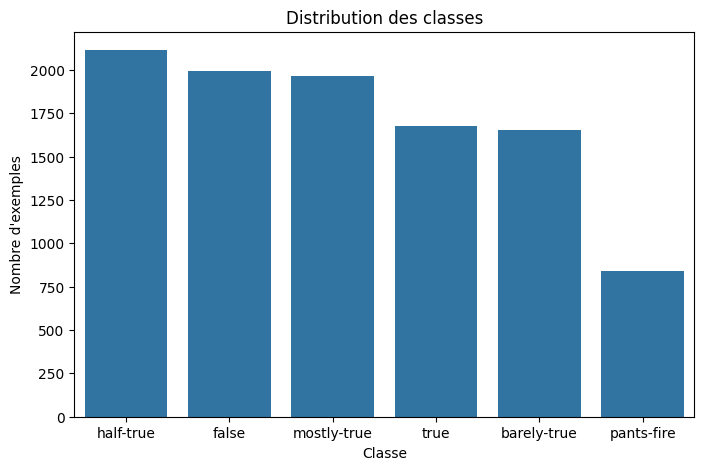

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=train,
    x="label",
    order=train["label"].value_counts().index
)

plt.title("Distribution des classes")
plt.xlabel("Classe")
plt.ylabel("Nombre d'exemples")

plt.show()

In [15]:
train["statement_length"] = train["statement"].apply(len)

train[["statement", "statement_length"]].head()

,statement,statement_length
0,Says the Annies List political group supports ...,82
1,When did the decline of coal start? It started...,141
2,"Hillary Clinton agrees with John McCain ""by vo...",105
3,Health care reform legislation is likely to ma...,78
4,The economic turnaround started at the end of ...,54


In [16]:
train["statement_length"].describe()

,statement_length
count,10240.000000
mean,106.918750
std,59.917722
min,11.000000
25%,73.000000
50%,99.000000
75%,132.250000
max,3192.000000


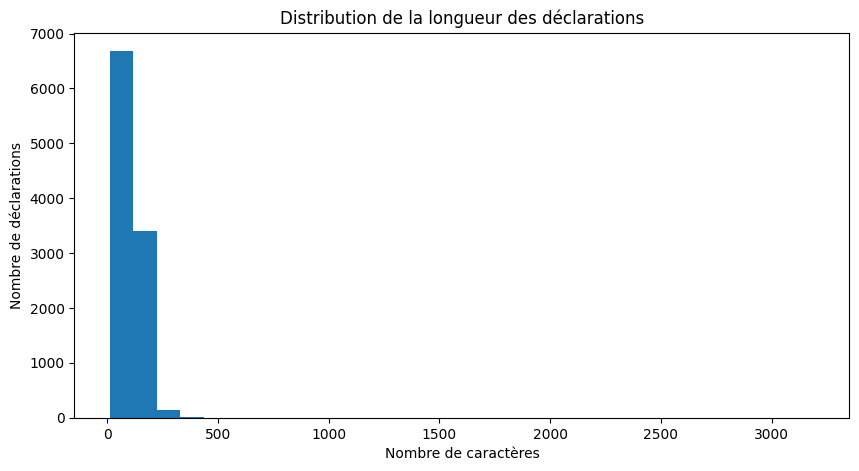

In [17]:
plt.figure(figsize=(10,5))

plt.hist(train["statement_length"], bins=30)

plt.title("Distribution de la longueur des déclarations")
plt.xlabel("Nombre de caractères")
plt.ylabel("Nombre de déclarations")

plt.show()

In [18]:
train.sort_values(
    by="statement_length",
    ascending=False
)[["statement","statement_length"]].head()

,statement,statement_length
1280,"Hospitals, doctors, MRIs, surgeries and so for...",3192
7550,The vast majority of the money I got was from ...,2099
6119,Georgia has the most restrictive ballot access...,1592
2142,The fact is that although we have had a presid...,538
9962,Barbara Buono by the numbers: As a Trenton pol...,395


In [19]:
train.sort_values(
    by="statement_length"
)[["statement","statement_length"]].head()

,statement,statement_length
1014,On abortion,11
6759,On torture.,11
709,On abortion,11
1071,On torture.,11
6527,On abortion.,12


In [20]:
missing = train.isnull().sum().sort_values(ascending=False)

missing

,0
speaker_job,2898
state_info,2210
context,102
subject,2
false_counts,2
party_affiliation,2
speaker,2
half_true_counts,2
mostly_true_counts,2
pants_on_fire_counts,2


In [21]:
missing_percent = (
    train.isnull().sum()
    / len(train)
    * 100
).sort_values(ascending=False)

missing_percent

,0
speaker_job,28.300781
state_info,21.582031
context,0.996094
subject,0.019531
false_counts,0.019531
party_affiliation,0.019531
speaker,0.019531
half_true_counts,0.019531
mostly_true_counts,0.019531
pants_on_fire_counts,0.019531


In [22]:
train_text = train.copy()
valid_text = valid.copy()
test_text = test.copy()

In [23]:
train_text = train_text[["statement", "label"]]
valid_text = valid_text[["statement", "label"]]
test_text = test_text[["statement", "label"]]

In [24]:
train_text.head()

,statement,label
0,Says the Annies List political group supports ...,false
1,When did the decline of coal start? It started...,half-true
2,"Hillary Clinton agrees with John McCain ""by vo...",mostly-true
3,Health care reform legislation is likely to ma...,false
4,The economic turnaround started at the end of ...,half-true


In [25]:
train_text.isnull().sum()

,0
statement,0
label,0
